**PREDICTION OF AQI FOR THE NEXT THREE DAYS**

 **DATA PREPROCESSING**

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
%matplotlib inline


In [107]:
!pip install shap



In [108]:
pip install captum

In [109]:
df=pd.read_csv('karachi_aqi.csv')

In [110]:
df

,date,time,hour_of_day,day_of_week,is_weekend,aqi_index,pm2_5,pm10,co,no2,...,forecast_22_pressure,forecast_22_wind_speed,forecast_23_temp,forecast_23_humidity,forecast_23_pressure,forecast_23_wind_speed,forecast_24_temp,forecast_24_humidity,forecast_24_pressure,forecast_24_wind_speed
0,2025-05-26,07:54:22,7,0,0,50,25.0,30.0,0.273896,39.585158,...,1006.761046,2.382054,31.912606,70.844937,1008.770777,2.485903,32.306147,74.404409,1008.334612,2.695458
1,2025-05-26,08:54:22,8,0,0,55,27.5,33.0,0.492346,23.999494,...,1010.752503,2.421003,28.645801,57.784812,1008.940121,1.893065,28.938965,51.150640,1011.203763,1.972421
2,2025-05-26,09:54:22,9,0,0,60,30.0,36.0,0.422252,26.932153,...,1015.612149,4.729462,25.265855,44.571243,1013.876865,5.014227,25.087299,47.506955,1013.939475,4.907536
3,2025-05-26,10:54:22,10,0,0,65,32.5,39.0,0.684510,39.738606,...,1011.656478,5.020915,34.634618,45.816371,1011.594391,5.204675,34.581434,46.348735,1010.544984,4.803836
4,2025-05-26,11:54:22,11,0,0,70,35.0,42.0,0.863638,15.157459,...,1013.123080,1.136499,33.219039,78.739660,1013.303922,1.443374,32.955727,79.384217,1011.378246,1.233817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2025-06-25,02:54:22,2,2,0,86,43.0,51.6,0.373439,30.011771,...,1006.599152,3.258978,35.249800,57.485779,1006.466843,2.109559,35.343962,62.288577,1006.043399,2.666795
716,2025-06-25,03:54:22,3,2,0,91,45.5,54.6,0.682181,20.621651,...,1013.417096,1.323995,25.876417,65.312420,1015.939235,0.570637,25.367694,62.510374,1012.198474,1.025967
717,2025-06-25,04:54:22,4,2,0,96,48.0,57.6,0.472216,24.026648,...,1012.347793,1.285434,31.895681,53.690417,1012.480999,0.882741,32.509490,50.137407,1009.146941,0.738453
718,2025-06-25,05:54:22,5,2,0,101,50.5,60.6,0.808149,12.982493,...,1009.765615,4.281019,30.648221,64.981801,1008.868699,4.910622,29.591960,66.419226,1008.897008,4.648168


In [111]:
print('LENGTH OF DATASET:',len(df))

LENGTH OF DATASET: 720


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Columns: 113 entries, date to forecast_24_wind_speed
dtypes: float64(107), int64(4), object(2)
memory usage: 635.8+ KB


In [113]:
df.isnull().sum()

,0
date,0
time,0
hour_of_day,0
day_of_week,0
is_weekend,0
...,...
forecast_23_wind_speed,0
forecast_24_temp,0
forecast_24_humidity,0
forecast_24_pressure,0


<Axes: >

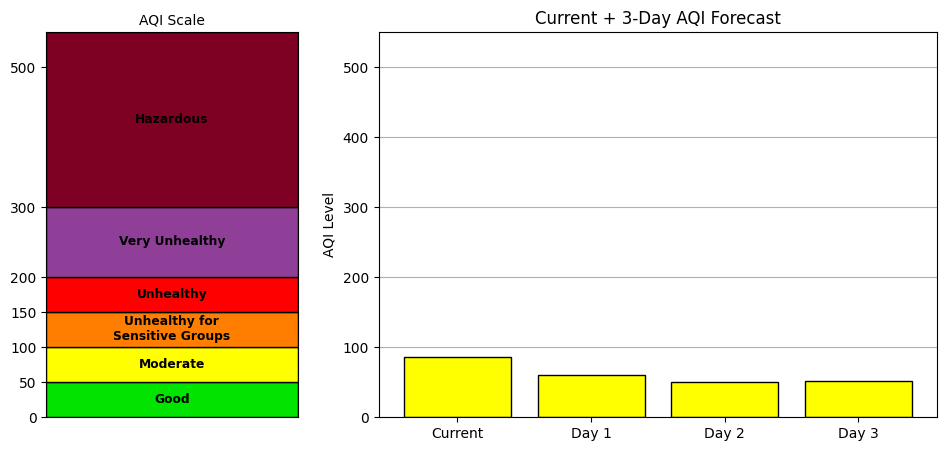

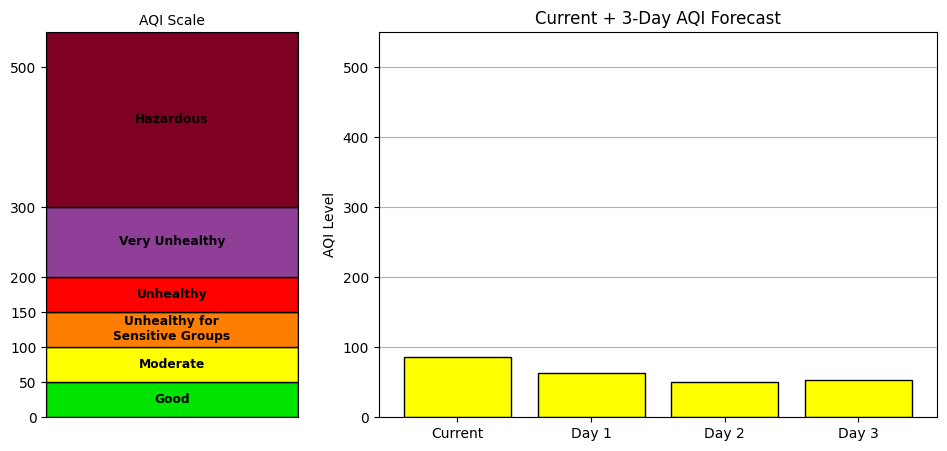

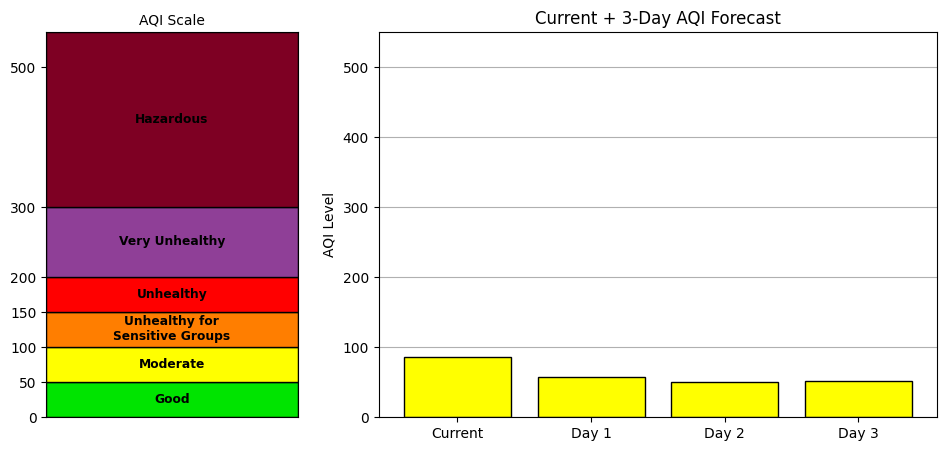

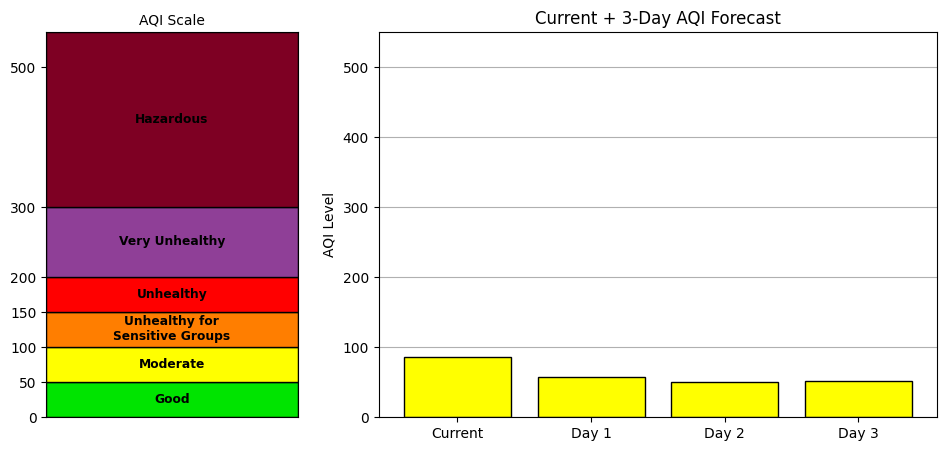

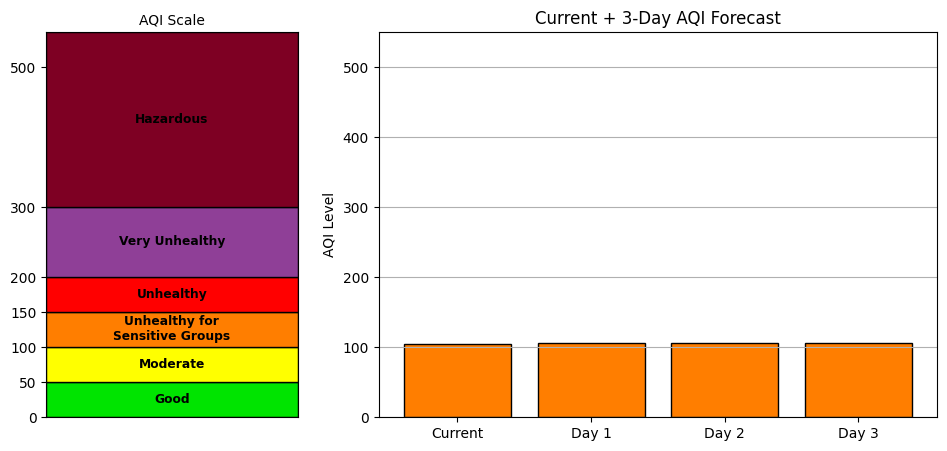

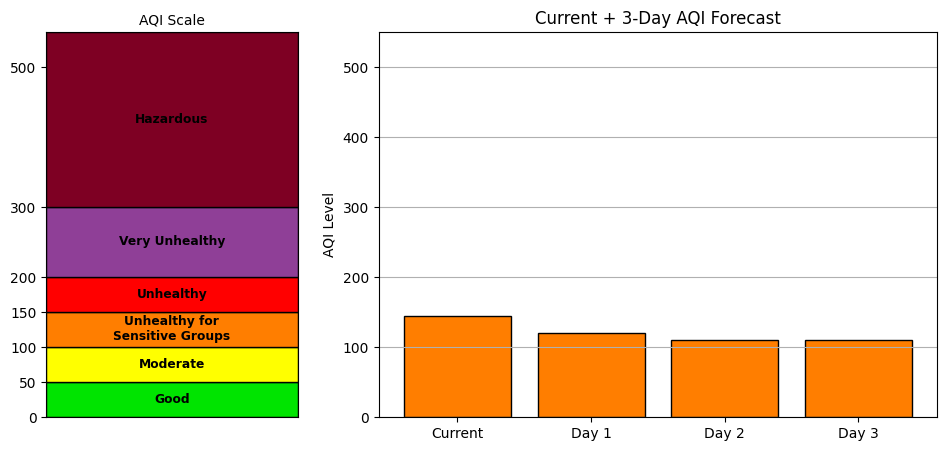

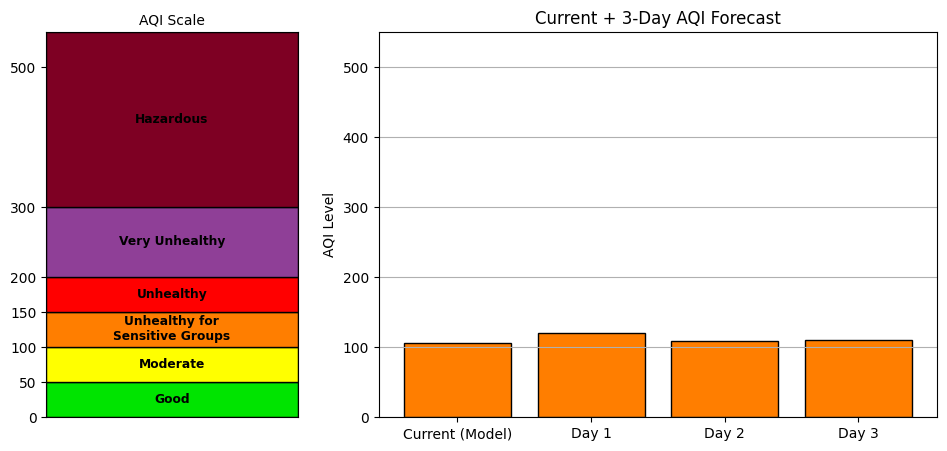

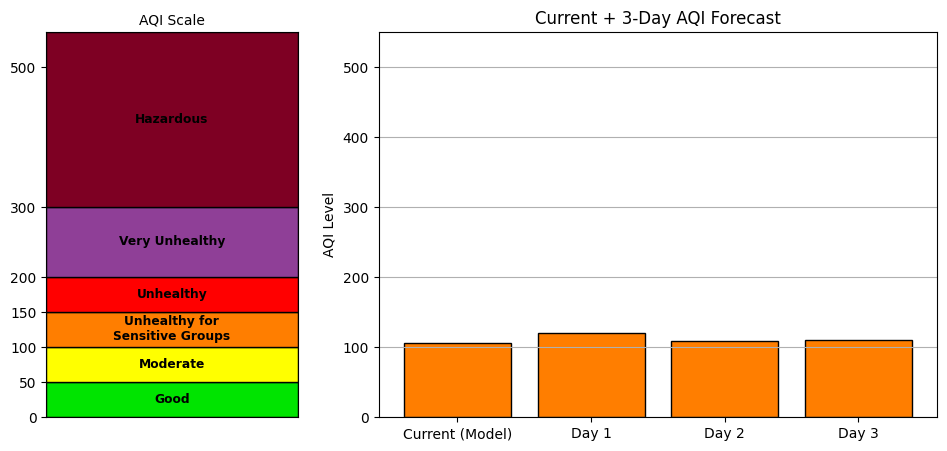

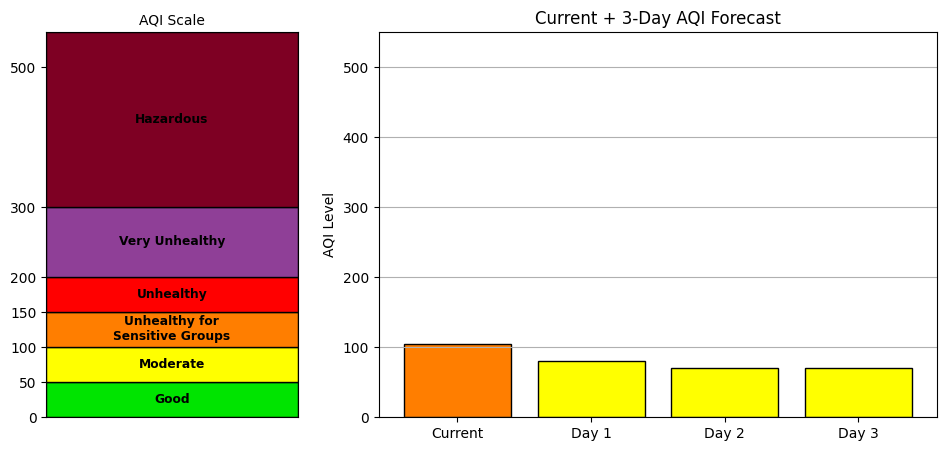

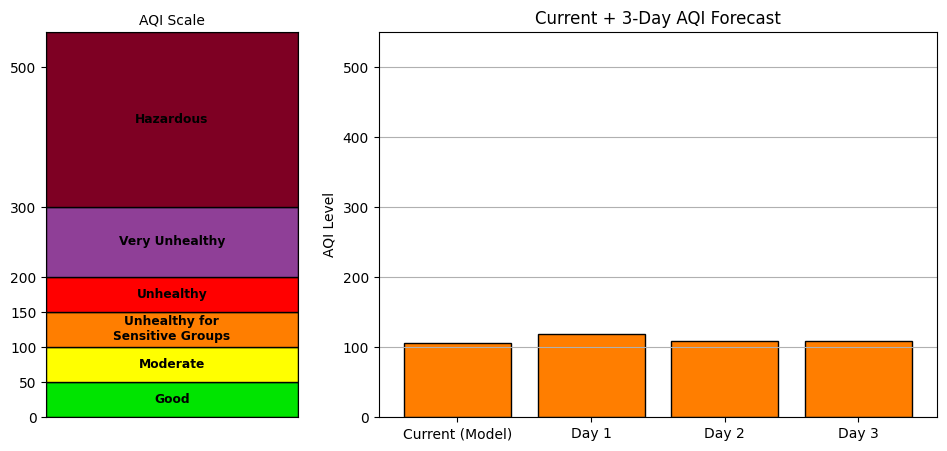

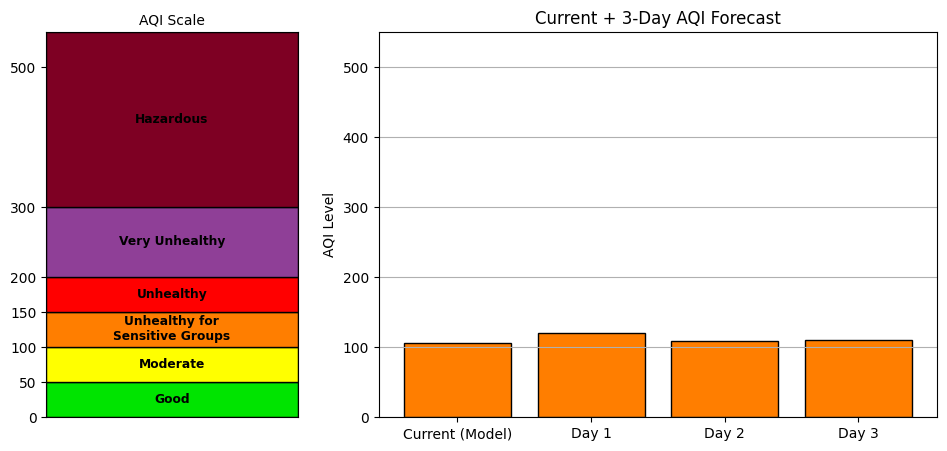

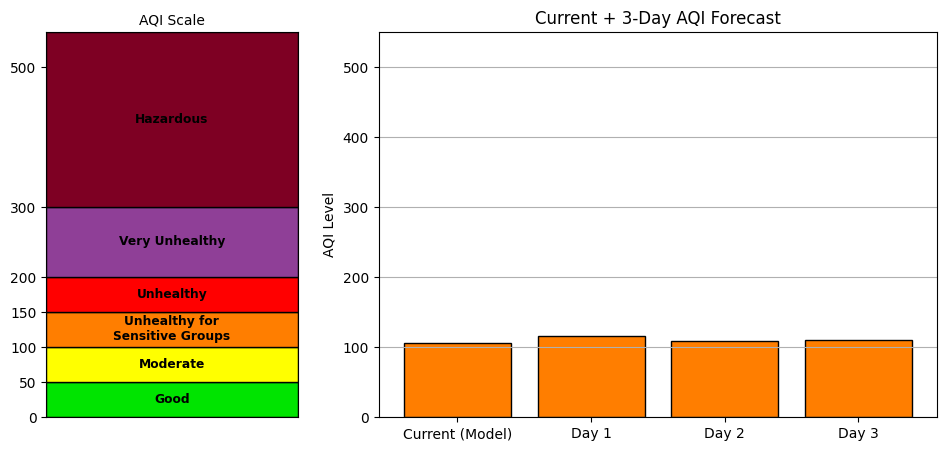

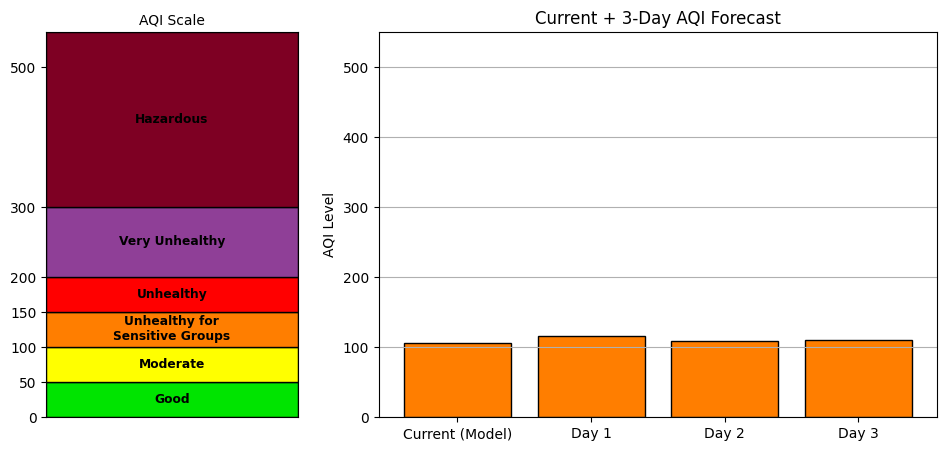

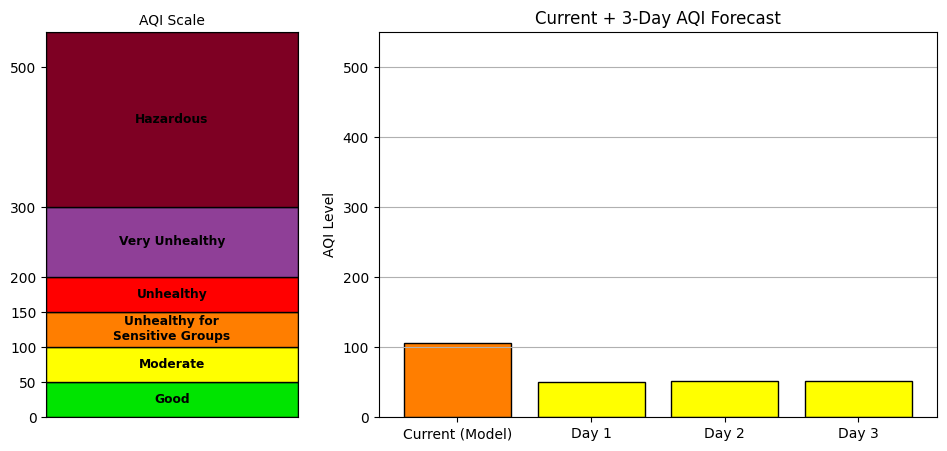

In [ ]:
#PLOTTING NULL VALUES
plt.figure(figsize=(25,25))
sns.heatmap(df.isnull())

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("karachi_aqi.csv")

# Show all columns for verification
print("Original columns:")
print(df.columns.tolist())

# Drop columns that contain 'forecast' (case-insensitive)
columns_to_drop = [col for col in df.columns if 'forecast' in col.lower()]
df.drop(columns=columns_to_drop, inplace=True)

# Show columns after deletion
print("\nRemaining columns:")
print(df.columns.tolist())

# Save cleaned file
df.to_csv("cleaned_file.csv", index=False)

In [ ]:
# Load the CSV
df1 = pd.read_csv("cleaned_file.csv")

In [ ]:
# Columns to delete
columns_to_delete = ["date", "time", "hour_of_day", "day_of_week", "is_weekend"]

# Drop the columns
df1.drop(columns=columns_to_delete, inplace=True)

# Optional: Save to a new CSV
df1.to_csv("cleaned1_file.csv", index=False)

# Show remaining columns
print(df1.columns.tolist())


In [ ]:
df1

**EXPLORATORY DATA ANALYSIS**

In [ ]:
#Summary Statistics

In [ ]:
df.describe()
df["aqi_index"].value_counts().sort_index()

In [ ]:
 #Time-Based Trends

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# STEP 1: Strip all column names of spaces
df.columns = df.columns.str.strip()

# STEP 2: Print column names to debug
print("COLUMNS:", df.columns.tolist())

# STEP 3: Parse 'date' and 'time' to create datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'], errors='coerce')

# STEP 4: Drop rows with invalid datetime
df = df.dropna(subset=['datetime'])

# STEP 5: Extract hour
df['hour'] = df['datetime'].dt.hour

# STEP 6: Get unique dates
unique_dates = df['datetime'].dt.date.unique()

# STEP 7: Define desired hour sequence (now includes 12 PM too)
desired_hours = list(range(12, 24)) + list(range(0, 12))  # 12 PM to 11 PM, then 12 AM to 11 AM

# STEP 8: Plot for each day
for day in unique_dates:
    day_df = df[df['datetime'].dt.date == day]

    # Get average AQI per hour
    hourly_avg = day_df.groupby(day_df['datetime'].dt.hour)['aqi_index'].mean()
    hourly_avg = hourly_avg.reindex(desired_hours)  # Ensure all desired hours are included

    # Create labels for each hour (same day or next day)
    hour_labels = []
    for hr in desired_hours:
        if hr >= 12:
            dt = pd.Timestamp(f"{day} {hr:02d}:00")
        else:
            dt = pd.Timestamp(f"{pd.Timestamp(day) + pd.Timedelta(days=1):%Y-%m-%d} {hr:02d}:00")
        hour_labels.append(dt)

    display_labels = [dt.strftime('%I %p') for dt in hour_labels]

    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(hour_labels, hourly_avg, color='skyblue', width=0.03)

    # Add AQI values on top of bars
    for bar, val in zip(bars, hourly_avg):
        if not pd.isna(val):
            plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{int(round(val))}',
                     ha='center', va='bottom', fontsize=8)

    plt.xticks(hour_labels, display_labels, rotation=0)
    plt.title(f"AQI in Karachi - {day} (12 PM to 11 AM Next Day)")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [ ]:
#Correlation Heatmap


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns (e.g., strings like 'time')
numeric_df = df.select_dtypes(include=["number"])

# Correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
# Daily Patterns

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Map weekday numbers to names
weekday_map = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

# Ensure 'day_of_week' column exists
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek  # 0 = Monday

# Group and rename index with weekday names
avg_aqi_by_day = df.groupby("day_of_week")["aqi_index"].mean()
avg_aqi_by_day.index = avg_aqi_by_day.index.map(weekday_map)

# Plot
ax = avg_aqi_by_day.plot(kind="bar", title="Average AQI by Day of Week", color="skyblue")
ax.set_ylabel("AQI")
ax.set_xlabel("Day")
plt.xticks(rotation=0)  # Keep weekday labels straight
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




In [ ]:
#Hourly Patterns

In [ ]:
import matplotlib.pyplot as plt

# Plot average AQI by hour with light blue bars
ax = df.groupby("hour_of_day")["aqi_index"].mean().plot(
    kind="bar",
    title="Average AQI by Hour",
    color='skyblue'  # light blue color
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("AQI")

plt.xticks(rotation=0)  # Keep hour labels straight (horizontal)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


FEATURE ENGINEERING

1. FOR TIME BASED FEATURES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import sys

# === CONFIGURATION ===
CSV_PATH = "karachi_aqi.csv"

# === Load data ===
if not os.path.exists(CSV_PATH):
    print(f"❌ File not found: {CSV_PATH}")
    sys.exit(1)

df = pd.read_csv(CSV_PATH)

# === Check required columns ===
required_cols = ["pm2_5", "date", "time"]
for col in required_cols:
    if col not in df.columns:
        print(f"❌ Missing required column: {col}")
        sys.exit(1)

df = df.dropna(subset=["pm2_5"])

# === Compute AQI from PM2.5 if not already present ===
def calculate_aqi_from_pm25(pm2_5):
    if pd.isna(pm2_5):
        return None
    if pm2_5 <= 12:
        return (50 / 12) * pm2_5
    elif pm2_5 <= 35.4:
        return ((100 - 51) / (35.4 - 12.1)) * (pm2_5 - 12.1) + 51
    elif pm2_5 <= 55.4:
        return ((150 - 101) / (55.4 - 35.5)) * (pm2_5 - 35.5) + 101
    else:
        return 200

if "AQI" not in df.columns:
    df["AQI"] = df["pm2_5"].apply(calculate_aqi_from_pm25)

df = df.dropna(subset=["AQI"])

# === Create timestamp ===
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("timestamp")

# === Feature selection ===
selected_features = [
    "pm2_5", "pm10", "co", "no2", "o3", "so2", "nh3",
    "temp", "humidity", "pressure", "wind_speed",
    "hour_of_day", "day_of_week", "is_weekend"
]
for i in range(1, 7):
    selected_features += [
        f"forecast_{i}_temp",
        f"forecast_{i}_humidity",
        f"forecast_{i}_pressure",
        f"forecast_{i}_wind_speed"
    ]

missing = [f for f in selected_features if f not in df.columns]
if missing:
    print(f"❌ Missing feature columns: {missing}")
    sys.exit(1)


In [ ]:
# Show columns after deletion
print("\nRemaining columns:")
print(df.columns.tolist())


 2. WITHOUT TIME BASED FEATURES

In [ ]:
# === CONFIGURATION ===
CSV_PATH = "cleaned1_file.csv"

# === Load data ===
if not os.path.exists(CSV_PATH):
    print(f"❌ File not found: {CSV_PATH}")
    sys.exit(1)

df1 = pd.read_csv(CSV_PATH)

# === Check required columns ===
required_cols = [
    'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3',
    'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed'
]

missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"❌ Missing required columns: {missing}")
    sys.exit(1)

df1 = df1.dropna(subset=["pm2_5", "aqi_index"])

# === Feature selection (NO timestamp or time-related features) ===
selected_features = [
    'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3',
    'temp', 'humidity', 'pressure', 'wind_speed'
]

target_col = "aqi_index"

# === Final check for features ===
missing_feats = [f for f in selected_features if f not in df.columns]
if missing_feats:
    print(f"❌ Missing feature columns: {missing_feats}")
    sys.exit(1)


TRAINING THE MODEL

1. WITH TIME BASED FEATURES

In [ ]:
X = df[selected_features].copy()
y = df["AQI"]

2. WITHOUT TIME BASED FEATURES

In [ ]:
# === Prepare data ===
X1 = df1[selected_features].copy()
y1 = df1[target_col]

1.  **LIGHTGBM MODEL - WITH TIME BASED FEATURES**

In [ ]:
# === TimeSeries Cross-validation ===
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
import shap  #  SHAP library

# === Drop constant or near-constant columns ===
X = X.loc[:, X.nunique() > 1]

# === TimeSeriesSplit ===
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list, r2_list = [], [], []

# === Define LightGBM ===
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print(" Training LightGBM...")

# === Cross-validation training and evaluation ===
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === Final full-data model training ===
model.fit(X, y)
joblib.dump(model, "model_lightgbm.pkl")


# === Predict full data for visualization ===
y_pred_all = model.predict(X)


# === Print average metrics ===
print("Evaluation Metrics :")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")




In [ ]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all[:100], label="Predicted AQI", linestyle="--")
plt.title("Predicted vs Actual AQI (LightGBM)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_lightgbm.png")


In [ ]:
# === SHAP Explainability ===
print("SHAP explanations")
explainer = shap.Explainer(model)
shap_values = explainer(X)

# === SHAP summary plot ===
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary_lightgbm.png")
print("Saved SHAP summary plot to shap_summary_lightgbm.png")

# === SHAP bar plot ===
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("shap_bar_lightgbm.png")
print(" Saved SHAP bar plot to shap_bar_lightgbm.png")

**1.LIGHTGBM MODEL - WITHOUT TIME BASED FEATURES**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
import shap  #  SHAP library

# === Drop constant or near-constant columns ===
X1 = X1.loc[:, X1.nunique() > 1]

# === TimeSeriesSplit ===
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list, r2_list = [], [], []

# === Define LightGBM ===
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print(" Training LightGBM...")


# === TimeSeriesSplit and Evaluation ===
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list, r2_list = [], [], []

# === Cross-validation training and evaluation ===
for train_idx, test_idx in tscv.split(X1):
    X2_train, X2_test = X1.iloc[train_idx], X1.iloc[test_idx]
    y2_train, y2_test = y1.iloc[train_idx], y1.iloc[test_idx]

    model.fit(X2_train, y2_train)
    y2_pred = model.predict(X2_test)

    mae_list.append(mean_absolute_error(y2_test, y2_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y2_test, y2_pred)))
    r2_list.append(r2_score(y2_test, y2_pred))

# === Final full-data model training ===
model.fit(X1, y1)
joblib.dump(model, "model_lightgbm1.pkl")


# === Predict full data for visualization ===
y_pred_all2 = model.predict(X1)



# === Print average metrics ===
print("Evaluation Metrics :")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")

In [ ]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y1.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all2[:100], label="Predicted AQI", linestyle="--")
plt.title("Predicted vs Actual AQI (LightGBM)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_lightgbm.png")

In [ ]:
# === SHAP Explainability ===
print("SHAP explanations")
explainer = shap.Explainer(model)
shap_values = explainer(X1)

# === SHAP summary plot ===
plt.figure()
shap.summary_plot(shap_values, X1, show=False)
plt.tight_layout()
plt.savefig("shap_summary_lightgbm.png")
print("Saved SHAP summary plot to shap_summary_lightgbm.png")

# === SHAP bar plot ===
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("shap_bar_lightgbm.png")
print(" Saved SHAP bar plot to shap_bar_lightgbm.png")

2. **XGBoost model - WITH TIME BASED FEATURES**

In [ ]:
from xgboost import XGBRegressor

# === XGBoost Model ===
model1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print("Training XGBoost")

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model1.fit(X_train, y_train)
    y_pred = model1.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === Final training ===
model1.fit(X, y)
joblib.dump(model1, "model_xgboost.pkl")


# === Predict full set ===
y_pred_all1 = model1.predict(X)


# === Evaluation Metrics ===
print("\nEvaluation Metrics (Average from XGBoost):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")







In [ ]:
# === ACTUAL vs PREDICTED PLOT ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all1[:100], label="Predicted AQI", linestyle="--")
plt.title("Predicted vs Actual AQI (XGBoost)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [ ]:
# === SHAP EXPLAINABILITY ===
print( "SHAP explanations")
explainer = shap.Explainer(model1, X)
shap_values = explainer(X)

# === SHAP Summary Plot ===
shap.summary_plot(shap_values, X)
# === SHAP Bar Plot ===
shap.plots.bar(shap_values)


3. RIDGE REGRESSION - WITH TIME BASED FEATURES

In [ ]:
from sklearn.linear_model import Ridge

# Drop constant columns (if any)
X = X.loc[:, X.nunique() > 1]

# === TimeSeries Split ===
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list, r2_list = [], [], []

# === Initialize Ridge Model ===
ridge_model = Ridge(alpha=1.0)

print("🚀 Training Ridge Regression Model...")

# === Cross-Validation Training ===
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === Final Model Training on Full Data ===
ridge_model.fit(X, y)
joblib.dump(ridge_model, "model_ridge.pkl")

# === Evaluation Results ===
print("\n✅ Ridge Regression Evaluation Metrics:")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")


In [ ]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all[:100], label="Predicted AQI", linestyle="--", color="orange")
plt.title("Predicted vs Actual AQI (Ridge Regression)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_ridge.png")


2. **XGBoost model - WITHOUT TIME BASED FEATURES**

In [ ]:
# === XGBoost Model ===
model1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print("Training XGBoost")

for train_idx, test_idx in tscv.split(X1):
    X3_train, X3_test = X1.iloc[train_idx], X1.iloc[test_idx]
    y3_train, y3_test = y1.iloc[train_idx], y1.iloc[test_idx]

    model1.fit(X3_train, y3_train)
    y3_pred = model1.predict(X3_test)

    mae_list.append(mean_absolute_error(y3_test, y3_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y3_test, y3_pred)))
    r2_list.append(r2_score(y3_test, y3_pred))

# === Final training ===
model1.fit(X1, y1)
joblib.dump(model1, "model_xgboost1.pkl")


# === Predict full set ===
y_pred_all3 = model1.predict(X1)


# === Evaluation Metrics ===
print("\nEvaluation Metrics (Average from XGBoost):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")

In [ ]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y1.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all3[:100], label="Predicted AQI", linestyle="--")
plt.title("Predicted vs Actual AQI (LightGBM)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_lightgbm.png")

In [ ]:
# === SHAP Explainability ===
print("SHAP explanations")
explainer = shap.Explainer(model1)
shap_values = explainer(X1)

# === SHAP summary plot ===
plt.figure()
shap.summary_plot(shap_values, X1, show=False)
plt.tight_layout()
plt.savefig("shap_summary_lightgbm.png")
print("Saved SHAP summary plot to shap_summary_lightgbm.png")

# === SHAP bar plot ===
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("shap_bar_lightgbm.png")
print(" Saved SHAP bar plot to shap_bar_lightgbm.png")

3. Regression Model  - WITH TIME BASED FEATURES


In [ ]:
# === Initialize Linear Regression Model ===
model2 = LinearRegression()
print("Linear Regression...")

# === TimeSeries Cross-validation Training ===
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model2.fit(X_train, y_train)
    y_pred = model2.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === Final Training on All Data ===
model2.fit(X, y)
joblib.dump(model2, "model_linear.pkl")
print("✅ Model saved to model_linear.pkl")

# === Predict on Full Dataset ===
y_pred_all2 = model2.predict(X)

# === Print Metrics ===
print("\n📈 Evaluation Metrics (Average from TimeSeriesSplit):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")




In [ ]:
# === Plot Actual vs Predicted ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all2[:100], label="Predicted AQI", linestyle="--", color="orange")
plt.title("Predicted vs Actual AQI (Linear Regression)")
plt.xlabel("Time (Sample Index)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === SHAP Explainability ===
print("🔍 Generating SHAP explanations...")
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# SHAP summary plot
shap.summary_plot(shap_values, X)

# SHAP bar plot
shap.plots.bar(shap_values)

3. Regression Model  - WITHOUT TIME BASED FEATURES

In [ ]:
# === Initialize Linear Regression Model ===
model2 = LinearRegression()
print("Linear Regression...")

# === TimeSeries Cross-validation Training ===
for train_idx, test_idx in tscv.split(X):
    X4_train, X4_test = X1.iloc[train_idx], X1.iloc[test_idx]
    y4_train, y4_test = y1.iloc[train_idx], y1.iloc[test_idx]

    model2.fit(X4_train, y4_train)
    y_pred4 = model2.predict(X4_test)

    mae_list.append(mean_absolute_error(y4_test, y_pred4))
    rmse_list.append(np.sqrt(mean_squared_error(y4_test, y_pred4)))
    r2_list.append(r2_score(y4_test, y_pred4))

# === Final Training on All Data ===
model2.fit(X1, y1)
joblib.dump(model2, "model_linear1.pkl")
print("✅ Model saved to model_linear.pkl")

# === Predict on Full Dataset ===
y_pred_all4 = model2.predict(X1)

# === Print Metrics ===
print("\n📈 Evaluation Metrics (Average from TimeSeriesSplit):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")
print(f"   Accuracy  : {np.mean(r2_list) * 100:.2f}%")


In [ ]:
# === Plot Actual vs Predicted ===
plt.figure(figsize=(12, 4))
plt.plot(y1.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all4[:100], label="Predicted AQI", linestyle="--", color="orange")
plt.title("Predicted vs Actual AQI (Linear Regression)")
plt.xlabel("Time (Sample Index)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**DEEP LEARNING MODEL**

LSTM - WITH TIME BASED FEATURES

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# === Load and clean data ===
df = pd.read_csv("karachi_aqi.csv")
df = df.dropna()

# Drop unnecessary columns
df = df.drop(columns=['date', 'time'], errors='ignore')

# Ensure AQI exists
if 'aqi_index' not in df.columns:
    raise ValueError("❌ 'aqi_index' column is missing!")

# Print actual AQI range before scaling
print("📊 AQI Range Before Scaling:")
print(f"Min AQI: {df['aqi_index'].min()} | Max AQI: {df['aqi_index'].max()}")

# === Add lag feature for AQI to simulate time context ===
for lag in range(1, 25):  # 24-hour lag
    df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

df = df.dropna()

# === Define target and features ===
target_col = 'aqi_index'
feature_cols = df.columns.tolist()
feature_cols.remove(target_col)

# === Scale features and target using RobustScaler ===
scaler_X = RobustScaler()
X_scaled = scaler_X.fit_transform(df[feature_cols])

scaler_y = RobustScaler()
y_scaled = scaler_y.fit_transform(df[[target_col]])

# === Create LSTM sequences (24-hour window) ===
sequence_length = 24
X_seq, y_seq = [], []

for i in range(sequence_length, len(X_scaled)):
    X_seq.append(X_scaled[i-sequence_length:i])
    y_seq.append(y_scaled[i])  # Predict AQI at time t

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# === Train-test split ===
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# === Build improved LSTM model ===
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.1),
    LSTM(64),
    Dropout(0.1),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')  # Use MAE loss
model.summary()

# === Early stopping ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# === Train model ===
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# === Predict and inverse scale ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# === Print predicted range
print("\n📈 AQI Range After Prediction:")
print(f"Min Predicted AQI: {y_pred.min():.2f}, Max Predicted AQI: {y_pred.max():.2f}")

# === Evaluation ===
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n=== Evaluation Metrics ===")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"R² Score  : {r2:.2f}")
print(f"Accuracy  : {r2 * 100:.2f}%")

# === Save model and scalers ===
model.save("model_lstm_aqi_fixed.keras")
joblib.dump(scaler_X, "scaler_X_fixed.save")
joblib.dump(scaler_y, "scaler_y_fixed.save")






In [ ]:
# === Plot training loss ===
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === Plot predicted vs actual AQI ===
plt.figure(figsize=(12, 5))
plt.plot(y_true[:200], label='Actual AQI')
plt.plot(y_pred[:200], label='Predicted AQI')
plt.title('AQI: Actual vs LSTM Prediction')
plt.xlabel('Time Steps')
plt.ylabel('AQI Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === Plot predicted AQI distribution ===
plt.figure(figsize=(8, 4))
plt.hist(y_pred, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Predicted AQI Values')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


2. LSTM - WITHOUT TIME BASED FEATURES

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# === Load and prepare data ===
df = pd.read_csv("karachi_aqi.csv")
df = df.dropna()

# Define desired features
selected_features = ['aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed']

# Filter only required columns
df = df[selected_features]

# Define target and features
target_col = "aqi_index"
feature_cols = [col for col in selected_features if col != target_col]

# Scale features
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df[feature_cols])

# Scale target
target_values = df[target_col].values.reshape(-1, 1)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(target_values)

# === Create sequences for LSTM ===
sequence_length = 24  # using past 24 hours to predict next AQI
X_seq, y_seq = [], []
for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y_scaled[i+sequence_length])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# === Train/test split ===
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# === Define LSTM model ===
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# === Train ===
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# === Predict and inverse scale ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


In [ ]:
# === Evaluation ===
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\nEvaluation Metrics:")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"R^2 Score : {r2:.2f}")

# === Save model and scalers ===
model.save("model1_lstm.keras")                     # Saves the LSTM model
joblib.dump(scaler_X, "scaler_X1.save")             # Saves feature scaler
joblib.dump(scaler_y, "scaler_y1.save")             # Saves target scaler

print("✅ Model and scalers saved successfully.")

In [ ]:
# === Plot predictions ===
plt.figure(figsize=(12, 5))
plt.plot(y_true[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred[:100], label="Predicted AQI", linestyle="--")
plt.title("LSTM Predicted vs Actual AQI")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_predicted_vs_actual.png")

 **INFERENCE**

PREDICTION USING LIGHTGBM MODEL

1. USING DATETIME FROM DATASET - TRAINING



In [ ]:
# === Load trained LightGBM model ===
model = joblib.load("model_lightgbm.pkl")

# === Extract expected features from model ===
feature_columns = model.feature_name_

# === Load full feature dataset ===
df = pd.read_csv("karachi_aqi.csv")

# === Validate required features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f" Missing columns in karachi.csv: {missing_cols}")

# === Get last 72 rows (3 days of hourly data) ===
df_last = df.tail(72).copy()

# === Align features for prediction ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime (optional) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=len(X), freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")




2. USING CURRENT DATETIME - TESTING

In [ ]:
import datetime

# === Load trained LightGBM model ===
model = joblib.load("model_lightgbm.pkl")

# === Extract expected features from model ===
feature_columns = model.feature_name_

# === Load full feature dataset ===
df = pd.read_csv("karachi_aqi.csv")

# === Validate required features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f" Missing columns in karachi.csv: {missing_cols}")

# === Get last 72 rows (3 days of hourly data) ===
df_last = df.tail(72).copy()

# === Align features for prediction ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Generate timestamps (for current datetime ) ===
start_time = datetime.datetime.now()
timestamps = [start_time + datetime.timedelta(hours=i) for i in range(len(X))]

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days:")
for dt, pred in zip(timestamps, y_pred):
    print(f"{dt.strftime('%Y-%m-%d %H:%M:%S')} → AQI: {round(pred, 2)}")

PREDICTION USING XGBOOST MODEL

1. USING DATETIME FROM DATASET - TRAINING

In [ ]:
# === Load trained XGBoost model ===
model = joblib.load("model_xgboost.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full dataset with features ===
df = pd.read_csv("karachi_aqi.csv")

# === Check for missing features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in karachi_aqi.csv: {missing_cols}")

# === Get last 72 rows (3 days hourly data) ===
df_last = df.tail(72).copy()

# === Prepare features ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime column (if exists) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days using XGBoost:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")


2. USING CURRENT DATETIME - TESTING


In [ ]:
# === Load trained XGBoost model ===
model = joblib.load("model_xgboost.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full feature dataset ===
df = pd.read_csv("karachi_aqi.csv")

# === Validate required features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f" Missing columns in karachi.csv: {missing_cols}")

# === Get last 72 rows (3 days of hourly data) ===
df_last = df.tail(72).copy()

# === Align features for prediction ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Generate timestamps (for current datetime ) ===
start_time = datetime.datetime.now()
timestamps = [start_time + datetime.timedelta(hours=i) for i in range(len(X))]

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days:")
for dt, pred in zip(timestamps, y_pred):
    print(f"{dt.strftime('%Y-%m-%d %H:%M:%S')} → AQI: {round(pred, 2)}")

PREDICTION USING LINEAR REGRESSION MODEL

 1. USING DATETIME FROM DATASET - TRAINING

In [ ]:
# === Load trained Linear Regression model ===
model = joblib.load("model_linear.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full dataset with features ===
df = pd.read_csv("karachi_aqi.csv")

# === Check for missing features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in karachi_aqi.csv: {missing_cols}")

# === Get last 72 rows (3 days hourly data) ===
df_last = df.tail(72).copy()

# === Prepare features ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime column (if exists) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days using XGBoost:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")

2. USING CURRENT DATETIME - TESTING

In [ ]:
# === Load trained Linear Regression model ===
model = joblib.load("model_linear.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full feature dataset ===
df = pd.read_csv("karachi_aqi.csv")

# === Validate required features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f" Missing columns in karachi.csv: {missing_cols}")

# === Get last 72 rows (3 days of hourly data) ===
df_last = df.tail(72).copy()

# === Align features for prediction ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Generate timestamps (for current datetime ) ===
start_time = datetime.datetime.now()
timestamps = [start_time + datetime.timedelta(hours=i) for i in range(len(X))]

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days:")
for dt, pred in zip(timestamps, y_pred):
    print(f"{dt.strftime('%Y-%m-%d %H:%M:%S')} → AQI: {round(pred, 2)}")

PREDICTION USING DEEP LEARNING MODEL

1. USING DATETIME FROM DATASET - TRAINING

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# === Load LSTM model and scalers ===
model = load_model("model_lstm_aqi_fixed.keras")
scaler_X = joblib.load("scaler_X_fixed.save")
scaler_y = joblib.load("scaler_y_fixed.save")

# === Load and clean data ===
df = pd.read_csv("karachi_aqi.csv").dropna()
df = df.drop(columns=["date", "time"], errors="ignore")

# Ensure 'aqi_index' exists
target_col = "aqi_index"
if target_col not in df.columns:
    raise ValueError("❌ 'aqi_index' column is missing from the dataset!")

# === Recreate the lag features needed by the model ===
for lag in range(1, 25):
    df[f"aqi_index_lag_{lag}"] = df[target_col].shift(lag)

df = df.dropna()

# === Ensure correct feature order as used in training ===
feature_cols = scaler_X.feature_names_in_
df = df[list(feature_cols) + [target_col]]

# === Get last 24 hours of data for prediction seed ===
latest_data = df.tail(24).copy()
X_input = scaler_X.transform(latest_data[feature_cols])
input_seq = np.array([X_input])  # shape = (1, 24, num_features)

# === Predict next 72 hours step-by-step ===
predictions = []

for _ in range(72):
    pred_scaled = model.predict(input_seq, verbose=0)[0][0]
    pred_actual = scaler_y.inverse_transform([[pred_scaled]])[0][0]
    predictions.append(pred_actual)

    # Prepare next input
    next_input = input_seq[0][1:].copy()       # Remove oldest step
    last_step = input_seq[0][-1].copy()        # Copy latest step

    # Update lag features with new prediction
    for i in range(1, 25):
        lag_col = f"aqi_index_lag_{i}"
        if lag_col in feature_cols:
            idx = list(feature_cols).index(lag_col)
            if len(predictions) >= i:
                last_step[idx] = predictions[-i]

    input_seq = np.append(next_input, [last_step], axis=0).reshape(1, 24, len(feature_cols))

# === Generate timestamps ===
start_time = pd.to_datetime("now").ceil("h")
timestamp_range = pd.date_range(start=start_time, periods=72, freq="H")

# === Print results ===
print("\n📈 Predicted AQI for Next 3 Days using LSTM:")
for dt, val in zip(timestamp_range, predictions):
    print(f"{dt} → AQI: {round(val, 2)}")


2. USING CURRENT DATETIME - TESTING

In [ ]:
import pandas as pd
import numpy as np
import joblib
import datetime
from tensorflow.keras.models import load_model

# === Load model and scalers ===
model = load_model("model_lstm_aqi_fixed.keras")
scaler_X = joblib.load("scaler_X_fixed.save")
scaler_y = joblib.load("scaler_y_fixed.save")

# === Load latest data ===
df = pd.read_csv("karachi_aqi.csv")

# === Recompute lag features for 'aqi_index' ===
target_col = "aqi_index"
for i in range(1, 25):
    df[f"{target_col}_lag_{i}"] = df[target_col].shift(i)

df = df.dropna()

# === Define features from scaler (used during training) ===
feature_cols = scaler_X.feature_names_in_
df = df[list(feature_cols) + [target_col]]

# === Prepare last 24 hours of input ===
latest_data = df.tail(24).copy()
X_input = scaler_X.transform(latest_data[feature_cols])

# === Forecast next 72 hours step by step ===
predictions = []
input_seq = np.array([X_input])  # shape: (1, 24, n_features)

for i in range(72):  # Predict next 72 hours
    pred_scaled = model.predict(input_seq, verbose=0)[0][0]
    pred_actual = scaler_y.inverse_transform([[pred_scaled]])[0][0]
    predictions.append(pred_actual)

    # Append last input again (can be improved later)
    next_input = np.append(input_seq[0][1:], [input_seq[0][-1]], axis=0)
    input_seq = np.expand_dims(next_input, axis=0)

# === Generate future timestamps ===
start_time = pd.to_datetime("now").ceil("H")
timestamps = [start_time + datetime.timedelta(hours=i) for i in range(72)]

# === Display predictions ===
print("\n📈 Predicted AQI for Next 3 Days using LSTM:")
for dt, pred in zip(timestamps, predictions):
    print(f"{dt.strftime('%Y-%m-%d %H:%M:%S')} → AQI: {round(pred, 2)}")




**DEPLOYMENT**

 USING GRADIO



1. PREDICTION OF AQI FOR THE NEXT 3 DAYS USING COLORS TO REPRESENT AQI LEVELS AND HOURLY AQI DATA GRAPH

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import datetime
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# === Color Mapping for AQI Levels ===
def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

# === Main Prediction Function ===
def predict_aqi(current_date_str, model_name):
    try:
        current_date = datetime.datetime.strptime(current_date_str, "%Y-%m-%d %H:%M:%S")
        #df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            if df_lstm.shape[0] < 24:
                return "Insufficient data for LSTM prediction", "", "", "", "", "", "", "", None

            X_input = df_lstm.tail(24)[feature_cols].values
            X_scaled = scaler_X.transform(X_input)
            input_seq = np.expand_dims(X_scaled, axis=0)

            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform([[pred_scaled]])[0][0]
                predictions.append(pred_actual)

                next_input = input_seq[0][-1].copy()
                next_seq = np.append(input_seq[0][1:], [next_input], axis=0)
                input_seq = np.expand_dims(next_seq, axis=0)

        # === Calculate Predictions ===
        timestamps = [current_date + datetime.timedelta(hours=i) for i in range(72)]
        predictions = np.array(predictions)
        daily_avgs = [np.mean(predictions[i*24:(i+1)*24]) for i in range(3)]
        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        # === Current AQI from latest data ===
        current_aqi = round(df["aqi_index"].iloc[-1])
        current_alert_level = get_alert_level(current_aqi)
        current_color = get_alert_color(current_alert_level)
        current_alert_html = f"<div style='background-color:{current_color};padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        # === Plot Hourly Line Chart ===
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(timestamps, predictions, color='skyblue', linewidth=2)
        ax.set_title(f"Hourly AQI Forecast - Model: {model_name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Predicted AQI")
        ax.grid(True)
        fig.autofmt_xdate()

        return (
            str(current_aqi), current_alert_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None

# === Gradio UI ===
with gr.Blocks(title="Karachi AQI Forecast ☁️", css="""
#predict-btn {
    background-color: skyblue !important;
    color: black !important;
    font-weight: bold;
    border-radius: 6px;
    padding: 10px 20px;
    border: 1px solid #0077cc;
}
""") as demo:

    gr.Markdown("## ☁️ Karachi Air Quality Forecast - Hourly AQI Prediction")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown(
            ["LightGBM", "XGBoost", "Ridge Regression", "LinearRegression", "LSTM"],
            label="Select Model"
        )

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI & Alert Level")
    with gr.Row():
        current_aqi_val = gr.Textbox(label="Current AQI")
        current_alert = gr.HTML()

    gr.Markdown("### 📅 Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="Hourly AQI Forecast (Next 72 Hours)")

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_val, current_alert,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot
        ]
    )

demo.launch()


In [ ]:
# === fastapi_app.py ===
from fastapi import FastAPI, Query
from fastapi.responses import JSONResponse
import pandas as pd
import numpy as np
import joblib
import datetime
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import io
import base64
from zoneinfo import ZoneInfo
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

app1 = FastAPI(title="Karachi AQI Forecast API")

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

@app.get("/predict")
def predict_aqi(
    current_date: str = Query(..., description="Date format: YYYY-MM-DD HH:MM:SS"),
    model_name: str = Query(..., description="Model: LightGBM, XGBoost, LinearRegression, Ridge Regression, LSTM")
):
    try:
        current_date = datetime.datetime.strptime(current_date, "%Y-%m-%d %H:%M:%S")
        df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            if df_lstm.shape[0] < 24:
                return JSONResponse(status_code=400, content={"error": "Insufficient LSTM data."})

            X_input = df_lstm.tail(24)[feature_cols].values
            X_scaled = scaler_X.transform(X_input)
            input_seq = np.expand_dims(X_scaled, axis=0)

            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform([[pred_scaled]])[0][0]
                predictions.append(pred_actual)

                next_input = input_seq[0][-1].copy()
                next_seq = np.append(input_seq[0][1:], [next_input], axis=0)
                input_seq = np.expand_dims(next_seq, axis=0)

        timestamps = [current_date + datetime.timedelta(hours=i) for i in range(72)]
        daily_avgs = [np.mean(predictions[i*24:(i+1)*24]) for i in range(3)]
        aqi_values = [round(val) for val in daily_avgs]

        current_aqi = round(df["aqi_index"].iloc[-1])
        alert_levels = [get_alert_level(val) for val in [current_aqi] + aqi_values]

        # Plot line chart
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(timestamps, predictions, color='skyblue', linewidth=2)
        ax.set_title(f"Hourly AQI Forecast - Model: {model_name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Predicted AQI")
        ax.grid(True)
        fig.autofmt_xdate()

        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        plot_base64 = base64.b64encode(buf.read()).decode('utf-8')

        return {
            "current_aqi": current_aqi,
            "current_alert": alert_levels[0],
            "forecast": {
                "day_1": {"aqi": aqi_values[0], "alert": alert_levels[1]},
                "day_2": {"aqi": aqi_values[1], "alert": alert_levels[2]},
                "day_3": {"aqi": aqi_values[2], "alert": alert_levels[3]}
            },
            "plot_image_base64": plot_base64
        }

    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})


In [ ]:
app1

2. PREDICTION OF AQI FOR THE NEXT 3 DAYS USING DAILY AQI DATA

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
import joblib
import datetime
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# === Color Mapping for AQI Levels ===
def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

# === Main Prediction Function ===
def predict_aqi(current_date_str, model_name):
    try:
        current_date = datetime.datetime.strptime(current_date_str, "%Y-%m-%d %H:%M:%S")
        df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            X_last = df_lstm.tail(24)[feature_cols]
            if X_last.shape[0] < 24:
                return "Insufficient data for LSTM prediction", "", "", "", "", "", "", "", None

            scaled_input = scaler_X.transform(X_last)
            input_seq = np.expand_dims(scaled_input, axis=0)

            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform(np.array([[pred_scaled]]))[0][0]
                predictions.append(pred_actual)

                next_input = input_seq[0][-1].copy()
                next_seq = np.append(input_seq[0][1:], [next_input], axis=0)
                input_seq = np.expand_dims(next_seq, axis=0)

        predictions = np.array(predictions)
        daily_avgs = [np.mean(predictions[i * 24:(i + 1) * 24]) for i in range(3)]
        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        current_aqi = round(df["aqi_index"].iloc[-1])
        current_alert_level = get_alert_level(current_aqi)
        current_color = get_alert_color(current_alert_level)
        current_alert_html = f"<div style='background-color:{current_color};padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        # === Plot without bar shadow ===
        fig = plt.figure(figsize=(11.5, 5))
        spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1.8, 4])

        ax_scale = fig.add_subplot(spec[0])
        ax = fig.add_subplot(spec[1])

        levels = [
            (0, 50, "Good", "#00e400"),
            (51, 100, "Moderate", "#ffff00"),
            (101, 150, "Unhealthy for Sensitive Groups", "#ff7e00"),
            (151, 200, "Unhealthy", "#ff0000"),
            (201, 300, "Very Unhealthy", "#8f3f97"),
            (301, 550, "Hazardous", "#7e0023")
        ]

        for low, high, label, color in levels:
            wrapped_label = "\n".join(textwrap.wrap(label, width=20))
            ax_scale.barh(
                y=(low + high) / 2,
                width=1,
                height=high - low,
                color=color,
                edgecolor="black"
            )
            ax_scale.text(
                0.5, (low + high) / 2,
                wrapped_label,
                va="center", ha="center",
                fontsize=8.8, weight="bold", color="black"
            )

        ax_scale.set_ylim(0, 550)
        ax_scale.set_xlim(0, 1)
        tick_vals = [0, 50, 100, 150, 200, 300, 550]
        tick_labels = ["0", "50", "100", "150", "200", "300", "500"]
        ax_scale.set_yticks(tick_vals)
        ax_scale.set_yticklabels(tick_labels)
        ax_scale.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax_scale.set_title("AQI Scale", fontsize=10)

        bars = ["Current Day", "Day 1", "Day 2", "Day 3"]
        bar_vals = [current_aqi] + daily_avgs
        bar_colors = [get_alert_color(get_alert_level(val)) for val in bar_vals]

        # Shadow removed here — this loop is now skipped
        # for i, val in enumerate(bar_vals):
        #     ax.axvspan(i - 0.4, i + 0.4, facecolor=get_alert_color(get_alert_level(val)), alpha=0.15)

        ax.bar(bars, bar_vals, color=bar_colors, edgecolor="black")
        ax.set_title("Current + 3-Day AQI Forecast")
        ax.set_ylabel("AQI Level")
        ax.set_ylim(0, max(bar_vals + [500]) + 50)
        ax.grid(True, axis='y')

        return (
            str(current_aqi), current_alert_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None

# === Gradio UI ===
with gr.Blocks(title="Karachi AQI Forecast", css="""
#predict-btn {
    background-color: skyblue !important;
    color: black !important;
    font-weight: bold;
    border-radius: 6px;
    padding: 10px 20px;
    border: 1px solid #0077cc;
}
""") as demo:

    gr.Markdown("## ☁️ Karachi Air Quality Forecast  |  Daily AQI Forecast Model - Next 3 Days")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown(
            ["LightGBM", "XGBoost", "Ridge Regression", "LinearRegression", "LSTM"],
            label="Select Model"
        )

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI & Alert Level")
    with gr.Row():
        current_aqi_box = gr.Textbox(label="Current AQI")
        current_alert = gr.HTML()

    gr.Markdown("### 🗕️ Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="AQI Forecast Plot")

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_box, current_alert,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot
        ]
    )

    demo.launch()


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
import joblib
import datetime
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# === Color Mapping for AQI Levels ===
def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

# === Main Prediction Function ===
def predict_aqi(current_date_str, model_name):
    try:
        current_date = datetime.datetime.strptime(current_date_str, "%Y-%m-%d %H:%M:%S")
         # df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            X_last = df_lstm.tail(24)[feature_cols]
            if X_last.shape[0] < 24:
                return "Insufficient data for LSTM prediction", "", "", "", "", "", "", "", None, ""

            scaled_input = scaler_X.transform(X_last)
            input_seq = np.expand_dims(scaled_input, axis=0)

            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform(np.array([[pred_scaled]]))[0][0]
                predictions.append(pred_actual)

                next_input = input_seq[0][-1].copy()
                next_seq = np.append(input_seq[0][1:], [next_input], axis=0)
                input_seq = np.expand_dims(next_seq, axis=0)

        predictions = np.array(predictions)
        daily_avgs = [np.mean(predictions[i * 24:(i + 1) * 24]) for i in range(3)]
        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        current_aqi = round(df["aqi_index"].iloc[-1])
        current_alert_level = get_alert_level(current_aqi)
        current_color = get_alert_color(current_alert_level)
        current_alert_html = f"<div style='background-color:{current_color};padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        # === Health Advisory Message ===
        advisory_message = {
            "Good": "Air quality is satisfactory. Enjoy your day!",
            "Moderate": "Air quality is acceptable. People who are unusually sensitive should limit outdoor exertion.",
            "Unhealthy for Sensitive Groups": "Sensitive groups may experience health effects. General public is less likely to be affected.",
            "Unhealthy": "Everyone may begin to experience health effects. Limit prolonged outdoor exertion.",
            "Very Unhealthy": "Health alert: serious health effects possible. Avoid outdoor activities.",
            "Hazardous": "Emergency conditions. Stay indoors and limit all exposure!"
        }.get(current_alert_level, "No advisory available.")

        advisory_html = f"<div style='background-color:{current_color};padding:12px;font-weight:bold;text-align:center;font-size:15px;color:white'>{advisory_message}</div>"

        # === Plot ===
        fig = plt.figure(figsize=(11.5, 5))
        spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1.8, 4])
        ax_scale = fig.add_subplot(spec[0])
        ax = fig.add_subplot(spec[1])

        levels = [
            (0, 50, "Good", "#00e400"),
            (51, 100, "Moderate", "#ffff00"),
            (101, 150, "Unhealthy for Sensitive Groups", "#ff7e00"),
            (151, 200, "Unhealthy", "#ff0000"),
            (201, 300, "Very Unhealthy", "#8f3f97"),
            (301, 550, "Hazardous", "#7e0023")
        ]

        for low, high, label, color in levels:
            wrapped_label = "\n".join(textwrap.wrap(label, width=20))
            ax_scale.barh(
                y=(low + high) / 2,
                width=1,
                height=high - low,
                color=color,
                edgecolor="black"
            )
            ax_scale.text(
                0.5, (low + high) / 2,
                wrapped_label,
                va="center", ha="center",
                fontsize=8.8, weight="bold", color="black"
            )

        ax_scale.set_ylim(0, 550)
        ax_scale.set_xlim(0, 1)
        tick_vals = [0, 50, 100, 150, 200, 300, 550]
        tick_labels = ["0", "50", "100", "150", "200", "300", "500"]
        ax_scale.set_yticks(tick_vals)
        ax_scale.set_yticklabels(tick_labels)
        ax_scale.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax_scale.set_title("AQI Scale", fontsize=10)

        bars = ["Current Day", "Day 1", "Day 2", "Day 3"]
        bar_vals = [current_aqi] + daily_avgs
        bar_colors = [get_alert_color(get_alert_level(val)) for val in bar_vals]

        ax.bar(bars, bar_vals, color=bar_colors, edgecolor="black")
        ax.set_title("Current + 3-Day AQI Forecast")
        ax.set_ylabel("AQI Level")
        ax.set_ylim(0, max(bar_vals + [500]) + 50)
        ax.grid(True, axis='y')

        return (
            str(current_aqi), current_alert_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig,
            advisory_html
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None, ""

# === Gradio UI ===
with gr.Blocks(title="Karachi AQI Forecast", css="""
#predict-btn {
    background-color: skyblue !important;
    color: black !important;
    font-weight: bold;
    border-radius: 6px;
    padding: 10px 20px;
    border: 1px solid #0077cc;
}
""") as demo:

    gr.Markdown("## ☁️ Karachi Air Quality Forecast  |  Daily AQI Forecast Model - Next 3 Days")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown(
            ["LightGBM", "XGBoost", "Ridge Regression", "LinearRegression", "LSTM"],
            label="Select Model"
        )

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI & Alert Level")
    with gr.Row():
        current_aqi_box = gr.Textbox(label="Current AQI")
        current_alert = gr.HTML()

    gr.Markdown("### 🗕️ Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="AQI Forecast Plot")

    gr.Markdown("### ⚠️ AQI Health Advisory")
    advisory_box = gr.HTML()

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_box, current_alert,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot,
            advisory_box
        ]
    )

    demo.launch()


In [ ]:
# fastapi_app.py
from fastapi import FastAPI, Query
from fastapi.responses import JSONResponse
import pandas as pd
import numpy as np
import joblib
import datetime
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
import io
import base64
from zoneinfo import ZoneInfo

app = FastAPI(title="Karachi AQI Forecast API")

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# === Color Mapping Function ===
def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

# === API Endpoint ===
@app.get("/predict")
def predict_aqi(
    current_date: str = Query(..., description="Date in format YYYY-MM-DD HH:MM:SS"),
    model_name: str = Query(..., description="Model name: LightGBM, XGBoost, LinearRegression, Ridge Regression, LSTM")
):
    try:
        current_date = datetime.datetime.strptime(current_date, "%Y-%m-%d %H:%M:%S")
        df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            X_last = df_lstm.tail(24)[feature_cols]
            if X_last.shape[0] < 24:
                return JSONResponse(status_code=400, content={"error": "Insufficient LSTM data."})

            scaled_input = scaler_X.transform(X_last)
            input_seq = np.expand_dims(scaled_input, axis=0)

            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform(np.array([[pred_scaled]]))[0][0]
                predictions.append(pred_actual)

                next_input = input_seq[0][-1].copy()
                next_seq = np.append(input_seq[0][1:], [next_input], axis=0)
                input_seq = np.expand_dims(next_seq, axis=0)

        predictions = np.array(predictions)
        daily_avgs = [np.mean(predictions[i * 24:(i + 1) * 24]) for i in range(3)]
        aqi_values = [round(val) for val in daily_avgs]
        current_aqi = round(df["aqi_index"].iloc[-1])
        alert_levels = [get_alert_level(val) for val in [current_aqi] + aqi_values]

        # Plotting
        fig = plt.figure(figsize=(11.5, 5))
        spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1.8, 4])

        ax_scale = fig.add_subplot(spec[0])
        ax = fig.add_subplot(spec[1])

        levels = [
            (0, 50, "Good", "#00e400"),
            (51, 100, "Moderate", "#ffff00"),
            (101, 150, "Unhealthy for Sensitive Groups", "#ff7e00"),
            (151, 200, "Unhealthy", "#ff0000"),
            (201, 300, "Very Unhealthy", "#8f3f97"),
            (301, 550, "Hazardous", "#7e0023")
        ]

        for low, high, label, color in levels:
            wrapped_label = "\n".join(textwrap.wrap(label, width=20))
            ax_scale.barh(
                y=(low + high) / 2,
                width=1,
                height=high - low,
                color=color,
                edgecolor="black"
            )
            ax_scale.text(
                0.5, (low + high) / 2,
                wrapped_label,
                va="center", ha="center",
                fontsize=8.8, weight="bold", color="black"
            )

        ax_scale.set_ylim(0, 550)
        ax_scale.set_xlim(0, 1)
        ax_scale.set_yticks([0, 50, 100, 150, 200, 300, 550])
        ax_scale.set_yticklabels(["0", "50", "100", "150", "200", "300", ">500"])
        ax_scale.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax_scale.set_title("AQI Scale", fontsize=10)

        bars = ["Current Day", "Day 1", "Day 2", "Day 3"]
        bar_vals = [current_aqi] + aqi_values
        bar_colors = [get_alert_color(get_alert_level(val)) for val in bar_vals]

        for i, val in enumerate(bar_vals):
            ax.axvspan(i - 0.4, i + 0.4, facecolor=get_alert_color(get_alert_level(val)), alpha=0.15)

        ax.bar(bars, bar_vals, color=bar_colors, edgecolor="black")
        ax.set_title("Current + 3-Day AQI Forecast")
        ax.set_ylabel("AQI Level")
        ax.set_ylim(0, max(bar_vals + [500]) + 50)
        ax.grid(True, axis='y')

        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')

        return {
            "current_aqi": current_aqi,
            "current_alert": alert_levels[0],
            "forecast": {
                "day_1": {"aqi": aqi_values[0], "alert": alert_levels[1]},
                "day_2": {"aqi": aqi_values[1], "alert": alert_levels[2]},
                "day_3": {"aqi": aqi_values[2], "alert": alert_levels[3]}
            },
            "plot_image_base64": img_base64
        }

    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})



In [ ]:
app

## ☁️ Karachi Air Quality Forecast  |  Real Time Daily AQI Forecast Model - Next 3 Days

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
import joblib
import datetime
import requests
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

IQAIR_API_KEY = "a1c4ea3c-c116-43fb-9d98-81004cf3f771"

def get_live_aqi():
    try:
        url = f"http://api.airvisual.com/v2/city?city=Karachi&state=Sindh&country=Pakistan&key={IQAIR_API_KEY}"
        response = requests.get(url)
        data = response.json()
        return data["data"]["current"]["pollution"]["aqius"]
    except:
        return None

def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

def predict_aqi(current_date_str, model_name):
    try:
        df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "LightGBM":
            model = joblib.load("model_lightgbm.pkl")
            X = df.tail(72)[model.feature_name_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "XGBoost":
            model = joblib.load("model_xgboost.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "LSTM":
            model = load_model("model_lstm_aqi_fixed.keras")
            scaler_X = joblib.load("scaler_X_fixed.save")
            scaler_y = joblib.load("scaler_y_fixed.save")
            feature_cols = scaler_X.feature_names_in_

            for lag in range(1, 25):
                df[f"aqi_index_lag_{lag}"] = df["aqi_index"].shift(lag)

            df_lstm = df[list(feature_cols) + ["aqi_index"]].dropna()
            X_last = df_lstm.tail(24)[feature_cols]
            if X_last.shape[0] < 24:
                return "Insufficient data for LSTM prediction", "", "", "", "", "", "", "", None, ""

            input_seq = np.expand_dims(scaler_X.transform(X_last), axis=0)
            for _ in range(72):
                pred_scaled = model.predict(input_seq, verbose=0)[0][0]
                pred_actual = scaler_y.inverse_transform([[pred_scaled]])[0][0]
                predictions.append(pred_actual)
                next_input = np.append(input_seq[0][1:], [input_seq[0][-1]], axis=0)
                input_seq = np.expand_dims(next_input, axis=0)

            current_pred = predictions[0]

        current_aqi = round(current_pred)
        daily_avgs = [np.mean(predictions[i * 24:(i + 1) * 24]) for i in range(3)]

        # === Apply correction to current AQI and forecast ===
        live_aqi = get_live_aqi()
        correction_factor = 0
        if live_aqi is not None:
            correction_factor = live_aqi - current_aqi
            current_aqi += correction_factor
            daily_avgs = [val + correction_factor for val in daily_avgs]

        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        current_alert_level = get_alert_level(current_aqi)
        current_html = f"<div style='background-color:{get_alert_color(current_alert_level)};padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        if live_aqi is not None:
            live_level = get_alert_level(live_aqi)
            live_html = f"<div style='background-color:{get_alert_color(live_level)};padding:8px;font-weight:bold;text-align:center'>{live_level}</div>"
            error_info = f"<div style='text-align:center;font-size:13px;color:#444'>Live vs Model AQI Error: ±{abs(live_aqi - current_aqi):.2f}</div>"
        else:
            live_html = "<div style='padding:8px;text-align:center'>Live AQI unavailable</div>"
            error_info = ""

        advisory = {
            "Good": "Air quality is satisfactory. Enjoy your day!",
            "Moderate": "Air quality is acceptable. Sensitive individuals should limit outdoor exertion.",
            "Unhealthy for Sensitive Groups": "Sensitive groups may experience health effects.",
            "Unhealthy": "Everyone may begin to experience health effects. Limit outdoor exertion.",
            "Very Unhealthy": "Health alert: serious effects possible. Avoid outdoor activities.",
            "Hazardous": "Emergency conditions. Stay indoors and limit exposure!"
        }.get(current_alert_level, "No advisory available.")

        advisory_html = f"<div style='background-color:{get_alert_color(current_alert_level)};padding:12px;font-weight:bold;text-align:center;font-size:15px;color:white'>{advisory}</div>{error_info}"

        # Plotting
        fig = plt.figure(figsize=(11.5, 5))
        spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1.8, 4])
        ax_scale = fig.add_subplot(spec[0])
        ax = fig.add_subplot(spec[1])

        for low, high, label, color in [
            (0, 50, "Good", "#00e400"),
            (51, 100, "Moderate", "#ffff00"),
            (101, 150, "Unhealthy for Sensitive Groups", "#ff7e00"),
            (151, 200, "Unhealthy", "#ff0000"),
            (201, 300, "Very Unhealthy", "#8f3f97"),
            (301, 550, "Hazardous", "#7e0023")
        ]:
            ax_scale.barh((low + high) / 2, 1, high - low, color=color, edgecolor="black")
            ax_scale.text(0.5, (low + high) / 2, "\n".join(textwrap.wrap(label, 20)), va="center", ha="center", fontsize=8.8, weight="bold")

        ax_scale.set_ylim(0, 550)
        ax_scale.set_xlim(0, 1)
        ax_scale.set_yticks([0, 50, 100, 150, 200, 300, 500])
        ax_scale.set_yticklabels(["0", "50", "100", "150", "200", "300", "500"])
        ax_scale.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_scale.set_title("AQI Scale", fontsize=10)

        bars = ["Current", "Day 1", "Day 2", "Day 3"]
        bar_vals = [current_aqi] + [float(v) for v in aqi_values]
        bar_colors = [get_alert_color(get_alert_level(v)) for v in bar_vals]

        ax.bar(bars, bar_vals, color=bar_colors, edgecolor="black")
        ax.set_title("Current + 3-Day AQI Forecast")
        ax.set_ylabel("AQI Level")
        ax.set_ylim(0, max(bar_vals + [500]) + 50)
        ax.grid(True, axis='y')

        return (
            str(round(current_aqi)), current_html,
            str(live_aqi) if live_aqi else "Unavailable", live_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig, advisory_html
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None, ""

# === Gradio Interface ===
with gr.Blocks(title="Karachi AQI Forecast", css="#predict-btn {background-color: skyblue !important; color: black !important; font-weight: bold; border-radius: 6px; padding: 10px 20px; border: 1px solid #0077cc;}") as demo:
    gr.Markdown("## ☁️ Karachi Air Quality Forecast  |  Real Time Daily AQI Forecast Model - Next 3 Days")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown(["LightGBM", "XGBoost", "Ridge Regression", "LinearRegression", "LSTM"], label="Select Model")

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI Values")
    with gr.Row():
        current_aqi_val = gr.Textbox(label="Model AQI", interactive=False)
        current_aqi_level = gr.HTML()
    with gr.Row():
        live_aqi_val = gr.Textbox(label="Live AQI (IQAir)", interactive=False)
        live_aqi_level = gr.HTML()

    gr.Markdown("### 🕕 Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="AQI Forecast Plot")
    gr.Markdown("### ⚠️ AQI Health Advisory")
    advisory_box = gr.HTML()

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_val, current_aqi_level,
            live_aqi_val, live_aqi_level,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot, advisory_box
        ]
    )

    demo.launch()
